In [1]:
#%pip install geopandas cartopy

In [29]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Patch
from cartopy.crs import PlateCarree
from cartopy.feature import BORDERS, COASTLINE, STATES

In [30]:
#HOME = Path().home()
#HPCHOME = HOME / "hpchome"
#LSS = HOME / "LSS"
#NICOLAS = LSS / "lss_nicolas"

plate_carre = PlateCarree()

In [31]:
usgs_gdf = gpd.read_file("usgs-basins.geojson") # gagues for the US

if usgs_gdf.crs != "EPSG:4326":
    usgs_gdf = usgs_gdf.to_crs(epsg=4326)

# np.loadtxt(NICOLAS / "DA/Zhihua/hlm_data/hlm_data/gauges_w_data.txt")
sangamon_gagues = [
    # "05578100",
    # "05578000",
    # "05579630",
    # "05576500",
    # "05580950",
    # "05577500",
    # "05576250",
    # "05576000",
    # "05580000",
    # "05582000",
    # "05576193",
    # "05583000",
    # "05570910",
    # "05578250",
    # "05576090",
    # "05573540",
    # "05578500",
    # "05579725",
    # "05579500",
    # "05572000",
#     
#     p1 = '05580950'
# p2 = '05579725'

    '05583000', # larger
    # '05578000',
    # '05576500',
    # '05582000',
    # '05573540',
    # '05576000',
    # '05572000',
    # '05578500',
    # '05576250',
    # '05570910',
    # '05580000',
    # '05579500',
    # '05577500',
    '05580950',
    '05579725',
    # '05579630',
]

# Catchmnet at each gague for the sangamon
usgs_subset = usgs_gdf[usgs_gdf['usgs_id'].isin(sangamon_gagues)].sort_values(by='area', ascending=False) # False
usgs_subset.usgs_id.values
# usgs_subset.to_file("05583000.geojson", driver='GeoJSON')

array(['05583000', '05580950', '05579725'], dtype=object)

In [32]:
#!pwd

/home/zli333/virtenvs/Hydro_cuda/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


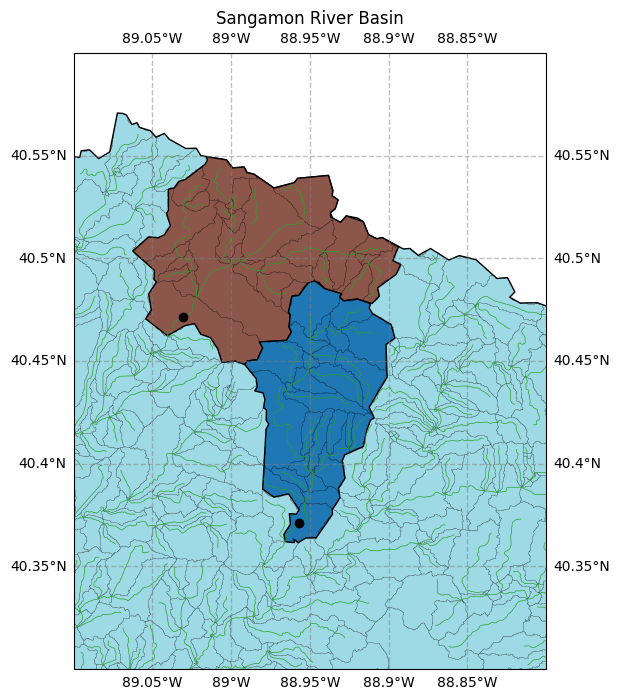

In [33]:
catchment = gpd.read_file("Catchment-05583000.gpkg") # hillslopes
# area = gpd.read_file("NHDArea-05583000.gpkg")
flowline = gpd.read_file("NHDFlowline-05583000.gpkg") # river network
# line = gpd.read_file("NHDLine-05583000.gpkg")
# waterbody = gpd.read_file("NHDWaterbody-05583000.gpkg")


gdf = gpd.read_file("sangamon-remove-holes_0.gpkg")

if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs(epsg=4326)


fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': plate_carre})

ax.add_feature(COASTLINE)
ax.add_feature(BORDERS)
ax.add_feature(STATES)

# catchment att each gague
usgs_subset.plot(ax=ax, column='usgs_id', cmap='tab20', legend=False, edgecolor='black')

# river network
flowline.plot(ax=ax, lw=0.5, color="C2")

# hillslopes
catchment.plot(ax=ax, facecolor="none", lw=0.1)

gl = ax.gridlines(draw_labels=True, crs=plate_carre, linewidth=1, color='gray', alpha=0.5, linestyle='--')

# we got this coordinates from NWM_USGS_CONUS.csv
lons = [-88.956642, -89.030457]
lats = [40.371162, 40.471527]
# 5579725	-9999	13551669	40.371162	-88.956642
# 5580950	-9999	13552723	40.471527	-89.030457

plt.scatter(lons, lats, transform=plate_carre, zorder=5, color="black")


plt.xlim(-89.1, -88.8) # limits for longitudes, West coordinates => negative values
plt.ylim(40.3, 40.6) # limits for latitudes


plt.title("Sangamon River Basin")
plt.show()


In [34]:
# LSS/lss_nicolas/DA/Zhihua/hlm_data/hlm_data/sangamon.gzip

In [37]:
usgs_subset = gpd.read_file("05583000.geojson") # gagues for the US


In [38]:
g05582000 = usgs_subset[usgs_subset.usgs_id == '05582000'].geometry.values[0]
g05579725 = usgs_subset[usgs_subset.usgs_id == '05579725'].geometry.values[0]

In [39]:
g05579725.contains(g05582000)

False

In [40]:
g05583000 = usgs_subset[usgs_subset.usgs_id == '05583000'].geometry.values[0]
g05578000 = usgs_subset[usgs_subset.usgs_id == '05578000'].geometry.values[0]
g05583000.contains(g05578000), g05578000.contains(g05583000)

(False, False)

In [41]:
a = usgs_subset[usgs_subset.usgs_id == '05578000'].geometry.values[0]
b = usgs_subset[usgs_subset.usgs_id == '05583000'].geometry.values[0]

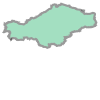

In [42]:
a.symmetric_difference(b)

In [43]:
c = b.symmetric_difference(a)

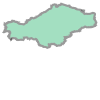

In [44]:
c


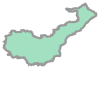

In [45]:
a

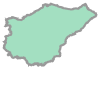

In [46]:
a.union(c)

In [47]:
c.area + a.area

1.3909583894517301

In [48]:
b.area

1.3909306642999992

In [49]:
p1 = '05580950'
p2 = '05579725'
a = usgs_subset[usgs_subset.usgs_id == p1].geometry.values[0]
b = usgs_subset[usgs_subset.usgs_id == p2].geometry.values[0]
c = b.symmetric_difference(a)

In [50]:
a.area, b.area, c.area

(0.009756453349999816, 0.00688891640000013, 0.016638896539419874)

In [51]:
a.area + b.area 
# c.area \approx a.area + b.area  => disjoint 

0.016645369749999944

In [23]:
# 5579725	-9999	13551669	40.371162	-88.956642
# 5580950	-9999	13552723	40.471527	-89.030457
